In [1]:
%load_ext autoreload
%autoreload 2
%pip install seaborn

""" Implementation of the nmf example using alternating projections instead of douglas-rachford."""
import numpy as np
from sklearn.decomposition import NMF
from jax import numpy as jnp
from optimize import AlternatingProjection, DouglassRachford
import projections
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:

### setup nmf problem    
samples=2
dimension=2
rankW = 2

Y = np.random.rand(dimension, rankW) @ np.random.rand(rankW, samples)  # generate low-rank matrix)
def minusMatrixVector(W,b):
    
    out = jnp.ones(W.shape[0])
    for i in range(W.shape[0]):
        out = out.at[i].set(np.linalg.norm(W[i,:].T-b))
    return out
def minusMatrixMatrix(W,B):
    W = jnp.array(W)
    out = jnp.zeros((W.shape[0], B.shape[1]))
    for i in range(W.shape[0]):
        for j in range(B.shape[1]):
            out = out.at[i,j].set(jnp.linalg.norm(W[i,:].T-B[:,j]))
    return out

iter 0
zezfzef [0.59582206 0.20597   ] 
 [[0.57313772 0.34994845]
 [0.36169089 0.46751754]] 
 [0.13671379 0.03531474] 
loss:l 0.32431546
new [0.5588568  0.15610322] 
 
 [[0.53827673 0.57121277]
 [0.4704823  0.34598678]] 
 [0.13671379 0.03531474] 
loss: 0.23626325
zezfzef [0.78957308 0.85528625] 
 [[0.53827673 0.57121277]
 [0.4704823  0.34598678]] 
 [0.79728941 0.34632813] 
loss:l 0.3965154
new [0.95641494 1.0423435 ] 
 
 [[0.19795299 0.18649977]
 [0.47712255 0.3565852 ]] 
 [0.79728943 0.34632814] 
loss: 0.7006504
iter 1
zezfzef [0.55885679 0.15610322] 
 [[0.36811486 0.37885627]
 [0.47380242 0.351286  ]] 
 [0.13671379 0.03531474] 
loss:l 0.3281388
new [0.5787404  0.13850746] 
 
 [[0.3183653  0.43695495]
 [0.48378453 0.32837892]] 
 [0.13671379 0.03531474] 
loss: 0.35794312
zezfzef [0.95641494 1.0423435 ] 
 [[0.3183653  0.43695495]
 [0.48378453 0.32837892]] 
 [0.79728941 0.34632813] 
loss:l 0.5390028
new [0.88736963 0.93531907] 
 
 [[0.30867067 0.42775664]
 [0.6315696  0.55162597]] 
 [0.7

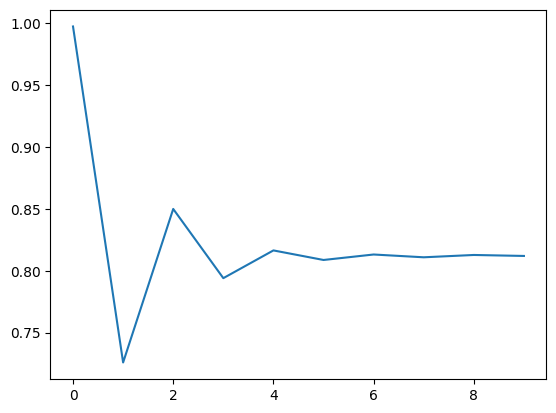

In [22]:
### nmf using alternating projections
W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
AP = DouglassRachford([], [projections.minusThingMatrix])
### perform nmf
norm = []
for iter in range(10):
    print("iter", iter)
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         print("zezfzef",X[:,k],"\n",W,"\n", Y[:,k],"\nloss:l",np.linalg.norm(minusMatrixVector(W.T, X[:,k]) -Y[:,k]))
         x, w, y = AP.step_layer(X[:,k],W, Y[:,k])
         print("new", x,"\n","\n", w,"\n",y,"\nloss:",np.linalg.norm( minusMatrixVector(w.T, x) -y))
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
    norm.append(np.linalg.norm( minusMatrixMatrix(W.T, X) - Y[:,k]))
plt.plot(norm)
print(W, X)
print("error", np.linalg.norm(W @ X - Y))

error 1.2287812e-07


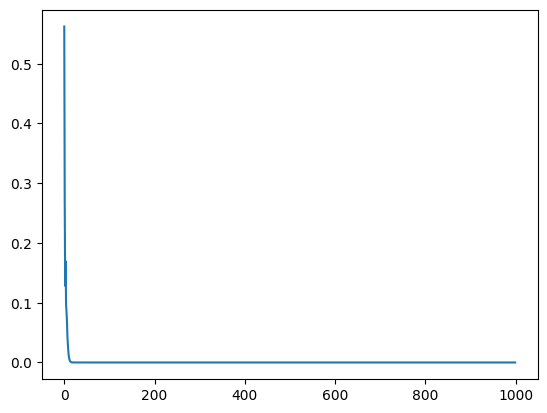

In [4]:
### nmf using douglas-rachford

W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
DR = DouglassRachford([projections.pos], [projections.bilinearMatrix])
### perform nmf
norm = []
for iter in range(1000):
    norm.append(np.linalg.norm( W @ X - Y))
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         x, w, y = DR.step_layer(X[:,k],W, Y[:,k])
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))

In [5]:
## image reconstruction example
from load_images import load_wxyz_data
## create batches of data
batchSize= 50
epochs = 30

images= load_wxyz_data()
print(images[0].shape)
batches= np.zeros((int(len(images)/batchSize),batchSize,images[0].shape[0]*images[0].shape[1]))
for i, img in enumerate(images):
    batches[i//batchSize, i%batchSize, :] = img.reshape(img.shape[0]*img.shape[1])
    
dimension= batches.shape[2]
samples = batches.shape[1]
rankW = 16



FileNotFoundError: [Errno 2] No such file or directory: 'benchmarkDataSets/wxyz_2k.txt'

In [ ]:
### nmf using douglas-rachford

W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
model = NMF(n_components=16, init='random', random_state=0)

AP = AlternatingProjection([], [projections.bilinearMatrixs])
### perform nmf
norm = []
for epoch in range(epochs):
    for batch in batches:
        Y = batch.T
        norm.append(np.linalg.norm( W @ X - Y)/(batchSize*samples))
        print("epoch", epoch, "batch error", norm[-1])
        X,W, Y = AP.step_layer(X,W, Y)
    print("epoch", epoch)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))


epoch 0 batch error 0.44942674937186294


KeyboardInterrupt: 

[[0.861265   0.5209416  0.9324325  ... 0.18637113 0.92094463 0.11965511]
 [0.46472847 0.92833877 0.15707076 ... 0.46593302 0.4397547  0.3605679 ]
 [0.76048034 0.5449774  0.26945442 ... 0.20145726 0.7156253  0.0995647 ]
 ...
 [0.9947679  0.40460983 0.28128722 ... 0.5024506  0.5452795  0.76960295]
 [0.16955127 0.3665553  0.2744739  ... 0.9529923  0.94280434 0.0346511 ]
 [0.29409015 0.06429933 0.6166405  ... 0.9012488  0.8822381  0.1776373 ]] [[0.96917737 0.2416002  0.84075874 ... 0.37566587 0.05495773 0.7048733 ]
 [0.6840831  0.16220845 0.44021648 ... 0.33641344 0.9715854  0.4429443 ]
 [0.14918573 0.22484672 0.6964739  ... 0.7786056  0.66088605 0.8904316 ]
 ...
 [0.9326357  0.11653    0.21866767 ... 0.15483204 0.6395942  0.48409218]
 [0.81269306 0.09243661 0.06421808 ... 0.37043136 0.40055203 0.2898232 ]
 [0.00619778 0.73777324 0.4024224  ... 0.01339716 0.6411533  0.31385815]]
W shape (1600, 16)
X shape (16, 500)
(1600, 1)
W_sklearn shape (1600, 16) X_sklearn shape (16, 500)
W_sklearn sh

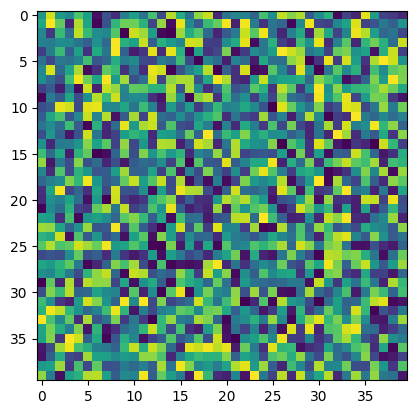

In [ ]:
print(W, X)
print("W shape", W.shape)
print( "X shape", X.shape)
testImg = np.ones((16,1))
print((W@ testImg).shape)
plt.imshow((W[:,1].reshape(40,40)))

model = NMF(n_components=16, init='random', random_state=0)
W_sklearn = model.fit_transform(batches[0].T)
print( "W_sklearn shape", W_sklearn.shape, "X_sklearn shape", model.components_.shape)
X_sklearn = model.components_
print("W_sklearn shape", W_sklearn.shape)
#plt.imshow(W_sklearn[:,3].reshape(40,40))




<Axes: xlabel='itteration', ylabel='reconn'>

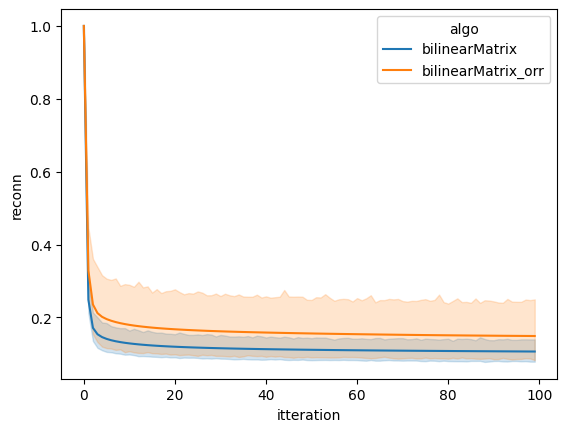

In [ ]:

import seaborn as sns
import pandas as pd

### perform nmf
norm = []
norm_orr = []
for test in range(10):
    dimension= np.random.randint(5,50)
    samples = np.random.randint(5,50)
    rankW = np.random.randint(2,min(dimension,samples))
    

    W = np.random.rand(dimension, rankW )
    X= np.random.rand(rankW, samples )
    Y = np.random.rand(dimension, samples )
    W_orr = np.copy(W)
    x_orr = np.copy(X)
    AP = AlternatingProjection([projections.pos], [projections.bilinearMatrix])
    AP_orr = AlternatingProjection([projections.pos], [projections.bilinearMatrix_orr])
    base_norm = np.linalg.norm( W @ X - Y)
    for iter in range(100):
        norm.append({"itteration":iter,"reconn":np.linalg.norm( W @ X - Y)/base_norm, "algo":"bilinearMatrix"})
        norm.append({"itteration":iter,"reconn":np.linalg.norm( W_orr @ x_orr - Y)/base_norm, "algo":"bilinearMatrix_orr"})
        for k in range(samples):
            x, w, y = AP.step_layer(X[:,k],W, Y[:,k])         
            X[:,k] = x        
            W = W + (1/(k+1))*(w - W)
            
            x_o, w_o, y_o = AP_orr.step_layer(x_orr[:,k],W_orr, Y[:,k])
            x_orr[:,k] = x_o
            W_orr = W_orr + (1/(k+1))*(w_o - W_orr)

sns.lineplot(pd.DataFrame(norm),  x="itteration", y="reconn", hue="algo")
